# **CIFO Project 25/26**

In this notebook, we'll develop a Genetic Algorithm to generate a minimalist version of *Girl with a Pearl Earring* by Johannes Vermeer.

The goal of this project is to approximate the original painting using a fixed number of geometric shapes, more specifically 100 triangles. Each triangle is defined by its position, shape, and color. Together, these triangles compose a generated image that should become as visually similar as possible to the original image.

This is an optimization problem because we are searching for the best possible combination of triangles among a very large number of possible solutions. To evaluate how good each generated image is, we compare it with the original image pixel by pixel using the **Root Mean Squared Error (RMSE)**. A lower RMSE means that the generated image is closer to the original one.

The final objective is not to reproduce the painting perfectly, but to explore how Genetic Algorithms can be used to solve a visual optimization problem through iterative improvement.

# Imports

Organizar imports!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [11]:
# Data Manipulation & Scientific Computing
import numpy as np
from sklearn.cluster import KMeans

# Visualization & Plotting 
import matplotlib.pyplot as plt

# Image Processing
from PIL import Image, ImageDraw
import imageio

# System & File Management
import os
import sys
from glob import glob
import importlib

# Logic, Structure & Functional Tools 
import random
import copy
from copy import deepcopy
from abc import ABC, abstractmethod
from itertools import product
import random
from functools import partial

# Custom Module Imports & Path Configuration
sys.path.append('C:\\Users\\Utilizador\\Desktop\\data science\\CIFO\\myversion')


import func_py_corrected
importlib.reload(func_py_corrected)

from func_py_corrected import *

print("Imports OK")

Imports OK


In [12]:
# Check the functions in python_func.py
print("Available functions in python_func.py:")
print(dir(sys.modules['func_py_corrected']))

Available functions in python_func.py:
['IMG_H', 'IMG_W', 'Image', 'ImageDraw', 'ImageFilter', 'KMeans', 'NUM_TRIANGLES', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_clamp', 'alpha_focus_mutation', 'apply_fitness_sharing', 'calculate_niche_counts', 'color_hard_mutation', 'color_soft_mutation', 'copy', 'creep_mutation', 'decode', 'fitness_rmse', 'mixed_mutation', 'np', 'one_point_crossover', 'phenotypic_distance', 'random', 'random_individual', 'random_triangle', 'render', 'shrink_triangle_mutation', 'tournament_selection', 'triangle_replacement_mutation', 'triangle_sort_mutation', 'triangular_sharing_function', 'two_point_crossover', 'uniform_triangle_crossover']


In [13]:
# Set random seeds for reproducibility
random.seed(42)

print ("Random seed set")

Random seed set


# Initial Analysis
First, we will load the target image and display it to understand what is our target:

Image shape: (400, 300, 4)  dtype: float32


(-0.5, 299.5, 399.5, -0.5)

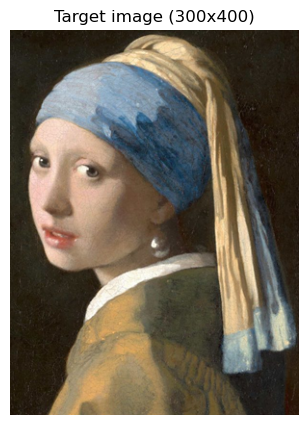

In [14]:

IMAGE_PATH = "girl_pearl_earing.png"    
IMG_W, IMG_H    = 300, 400

# Load target image
target = Image.open(IMAGE_PATH).convert("RGBA").resize((IMG_W, IMG_H))
target = np.array(target, dtype=np.float32)  # shape (H, W, 4)

print(f'Image shape: {target.shape}  dtype: {target.dtype}')

# Display target image
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(target.astype(np.uint8))
ax.set_title('Target image (300x400)')
ax.axis('off')


# Model Implementation
## Parameter Set-Up

Before implementing the Genetic Algorithm (GA), we define the fixed environment variables and the search space for hyperparameter tuning.

1. **Fixed Constants**

These parameters remain constant across all experiments to ensure a baseline for comparison.

| Parameter | Value | Description |
| :--- | :--- | :--- |
| **NUM_TRIANGLES** | 100 | Number of triangles per individual. |
| **NUM_GENERATIONS** | 5,000 | Maximum number of generations per run. |
| **STAGNATION_LIMIT** | 200 | Generations to wait for improvement before early stopping. |
| **SAVE_EVERY** | 100 | Frequency (in generations) to save image progress. |

2. **Hyperparameter Grid Search**

We use a grid search approach to find the optimal configuration for the evolution process.

- POP_SIZE: [30, 50, 100, 150, 200] — Total individuals per generation.

- TOURNAMENT_K: [2, 3, 5, 7] — Pressure for selection.

- ELITISM_COUNT: [1, 2, 5] — Number of top performers preserved.

- MUTATION_RATE: [0.01, 0.03, 0.05, 0.10, 0.15] — Probability of random changes.

- CROSSOVER_RATE: [0.5, 0.7, 0.9] — Probability of offspring inheriting from two parents.

>The stagnation limit was treated as a stopping criterion instead of a main parameter. 
>Therefore, it will be tuned (if needed) after selecting the main parameters, by comparing the final RMSE and execution time.

In [15]:
NUM_TRIANGLES   = 100               # number of triangles per individual defined fixed 100
SAVE_EVERY      = 100               # save image every N generations
NUM_GENERATIONS = 5000              # nr. generations
STAGNATION_LIMIT = 200              # limit for stagnation detection, treated as a stopping criterion

## Main Loop for the Genetic Algorithm

Now, we will implement the genetic algorithm:

In [16]:
def genetic_algorithm(
    initial_population,
    max_generations,
    selection_algorithm,
    xo_method,
    mut_method,
    target_array,
    tournament_k=5,
    maximization=False,
    xo_prob=0.9,
    mut_prob=0.2,
    elitism=True,
    elitism_count=1,
    color_palette=None,
    verbose=False,
    enable_fitness_sharing=False,
    niche_radius=100.0
):
    """
    Executes a genetic algorithm to optimize a population of solutions.

    Args:
        initial_population (list[Solution]): The starting population of solutions.
        max_generations (int): The maximum number of generations to evolve.
        selection_algorithm (Callable): Function used for selecting individuals.
        xo_method (Callable): Function used for crossover between two individuals.
        mut_method (Callable): Function used for mutating an individual.
        edge_prob_flat (np.ndarray): Flattened array of edge probabilities.
        target_array (np.ndarray): The target image array.
        maximization (bool, optional): If True, maximizes the fitness function; otherwise, minimizes. Defaults to False.
        xo_prob (float, optional): Probability of applying crossover. Defaults to 0.9.
        mut_prob (float, optional): Probability of applying mutation. Defaults to 0.2.
        elitism (bool, optional): If True, carries the best individual to the next generation. Defaults to True.
        verbose (bool, optional): If True, prints detailed logs for debugging. Defaults to False.
        enable_fitness_sharing (bool, optional): If True, applies fitness sharing. Defaults to False.
        niche_radius (float, optional): The radius for determining niches in fitness sharing. Defaults to 100.0.

    Returns:
        Solution: The best solution found on the last population after evolving for max_gen generations.
        list[float]: The fitness of the best individual over the generations
    """
    population = initial_population
    best_fitness_over_time = []

    for gen in range(max_generations):
        # Calculate raw fitness for all individuals
        raw_fitnesses = [fitness_rmse(ind, target) for ind in population]
        
        # Apply fitness sharing if enabled
        if enable_fitness_sharing:
            niche_counts = calculate_niche_counts(population, niche_radius)
            fitnesses = apply_fitness_sharing(raw_fitnesses, niche_counts)
            if verbose and gen % 100 == 0:
                avg_niche = np.mean(niche_counts)
                print(f"Generation {gen}: Avg Niche Count = {avg_niche:.2f}")
        else:
            fitnesses = raw_fitnesses

        best_fitness = max(raw_fitnesses) if maximization else min(raw_fitnesses)
        best_fitness_over_time.append(best_fitness)

        if verbose:
            print(f"Generation {gen}: Best Fitness = {best_fitness}")

        new_population = []

        # Elitism: carry the best individuals to the next generation unchanged
        if elitism and elitism_count > 0:
            elitism_count = min(elitism_count, len(population))
            elite_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=maximization)[:elitism_count]
            new_population.extend([deepcopy(population[i]) for i in elite_indices])

        best_idx = elite_indices[0] if (elitism and elitism_count > 0) else fitnesses.index(best_fitness)
        best_individual = population[best_idx]

        # Save intermediate images every SAVE_EVERY generations
        if gen % SAVE_EVERY == 0:
            img = render(best_individual)
            os.makedirs("output", exist_ok=True)
            plt.imsave(f"output/gen_{gen:04d}.png", img.astype(np.uint8))

        # Generate new population through selection, crossover, and mutation
        while len(new_population) < len(population):
            # Selection
            parent1 = selection_algorithm(population, fitnesses, tournament_k)
            parent2 = selection_algorithm(population, fitnesses, tournament_k)

            # Crossover
            offspring1, offspring2 = xo_method(parent1, parent2, xo_prob)
    
            # Mutation
            offspring1 = mut_method(offspring1, mut_prob)
            offspring2 = mut_method(offspring2, mut_prob)

            new_population.extend([offspring1, offspring2])

        population = new_population[:len(population)]

        # If no improvement for STAGNATION_LIMIT generations, partially reinitialize worst individuals
        if gen > STAGNATION_LIMIT and best_fitness_over_time[-1] == best_fitness_over_time[-STAGNATION_LIMIT]:
            n_replace = int(0.2 * len(population))
            worst_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:n_replace]
            for i in worst_indices:
                population[i] = random_individual()
            if verbose:
                print(f"Generation {gen}: Partial reinitialization of {n_replace} individuals")

    final_fitnesses = [fitness_rmse(ind, target) for ind in population]
    best_solution = deepcopy(population[
        final_fitnesses.index(max(final_fitnesses) if maximization else min(final_fitnesses))
    ])

    return best_solution, best_fitness_over_time

Random combinations of the parameters will be tested using only 500 generations during the first refinement phase, in order to reduce computational cost and identify promising configurations more efficiently:

In [ ]:
# ── Random Search ─────────────────────────────────────────────────────────────
SEARCH_GENERATIONS = 500
N_TRIALS           = 10   

param_space = {
    "POP_SIZE":       [50, 100, 150, 200],
    "TOURNAMENT_K":   [3, 5, 7, 10],
    "MUTATION_RATE":  [0.05, 0.1, 0.2, 0.3, 0.4],
    "CROSSOVER_RATE": [0.1, 0.3, 0.5, 0.7, 0.9],
    "ELITISM_COUNT":  [1, 2, 5, 10],
    "MUT_WEIGHTS": [
        [0.25, 0.20, 0.10, 0.10, 0.15, 0.10, 0.10],  
        [0.40, 0.30, 0.05, 0.05, 0.10, 0.05, 0.05],  
        [0.10, 0.30, 0.10, 0.05, 0.10, 0.10, 0.25],  
        [0.15, 0.15, 0.20, 0.15, 0.15, 0.10, 0.10],  
    ],
}

def sample_params(space):
    return {k: random.choice(v) for k, v in space.items()}

def make_key(p):
    return tuple(
        tuple(v) if isinstance(v, list) else v
        for v in p.values()
    )

sampled = []
seen    = set()
while len(sampled) < N_TRIALS:
    p = sample_params(param_space)
    key = make_key(p)
    if key not in seen:
        seen.add(key)
        sampled.append(p)

final_images    = []
final_fitnesses = []
best_fitnesses  = []
histories       = []
all_params      = []

for i, params in enumerate(sampled):

    print(f"\n── Trial {i+1}/{N_TRIALS} | {params}")

    POP_SIZE       = params["POP_SIZE"]
    TOURNAMENT_K   = params["TOURNAMENT_K"]
    MUTATION_RATE  = params["MUTATION_RATE"]
    CROSSOVER_RATE = params["CROSSOVER_RATE"]
    ELITISM_COUNT  = params["ELITISM_COUNT"]
    MUT_WEIGHTS    = params["MUT_WEIGHTS"]

    population = [random_individual() for _ in range(POP_SIZE)]
    mut_method = partial(mixed_mutation, weights=MUT_WEIGHTS)

    best_dna, history = genetic_algorithm(
        initial_population  = population,
        max_generations     = SEARCH_GENERATIONS,
        selection_algorithm = tournament_selection,
        xo_method           = uniform_triangle_crossover,
        mut_method          = mut_method,
        target_array        = target,
        tournament_k        = TOURNAMENT_K,
        maximization        = False,
        xo_prob             = CROSSOVER_RATE,
        mut_prob            = MUTATION_RATE,
        elitism             = True,
        elitism_count       = ELITISM_COUNT,
        verbose             = False,
        enable_fitness_sharing = False,
    )

    final_fitness = history[-1]
    best_fitness  = float(np.min(history))

    final_images.append(render(best_dna))
    final_fitnesses.append(final_fitness)
    best_fitnesses.append(best_fitness)
    histories.append(history)
    all_params.append(params)

    print(f"Final RMSE: {final_fitness:.4f} | Best RMSE: {best_fitness:.4f}")


── Trial 1/10 | {'POP_SIZE': 50, 'TOURNAMENT_K': 3, 'MUTATION_RATE': 0.2, 'CROSSOVER_RATE': 0.3, 'ELITISM_COUNT': 2, 'MUT_WEIGHTS': [0.4, 0.3, 0.05, 0.05, 0.1, 0.05, 0.05]}


Best combination (trial 10):
   POP_SIZE: 200
   TOURNAMENT_K: 7
   MUTATION_RATE: 0.3
   CROSSOVER_RATE: 0.5
   ELITISM_COUNT: 2
   MUT_WEIGHTS: [0.1, 0.3, 0.1, 0.05, 0.1, 0.1, 0.25]
   Final RMSE: 36.3268


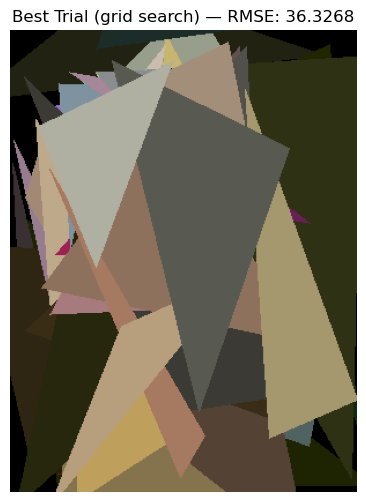

In [9]:
# Save results of grid search
best_trial_index  = int(np.argmin(final_fitnesses))
best_params       = all_params[best_trial_index]

print(f"Best combination (trial {best_trial_index+1}):")
for k, v in best_params.items():
    print(f"   {k}: {v}")
print(f"   Final RMSE: {final_fitnesses[best_trial_index]:.4f}")

# Visualise image of grid search
plt.figure(figsize=(5, 6))
plt.imshow(final_images[best_trial_index].astype(np.uint8))
plt.title(f"Best Trial (grid search) — RMSE: {final_fitnesses[best_trial_index]:.4f}")
plt.axis("off")
plt.show()

In [ ]:
def plot_convergence(crossovers, generations, **ga_params):
    plt.figure(figsize=(10, 5))
    
    # remove parameters not relevant for convergence plotting
    pop_size = ga_params.pop("POP_SIZE")
    ga_params.pop("MUT_WEIGHTS", None)  
    
    for name, xo in crossovers.items():
        population = [random_individual() for _ in range(pop_size)]
        _, history = genetic_algorithm(
            initial_population=population,
            xo_method=xo,
            max_generations=generations,
            **ga_params
        )
        plt.plot(history, label=name)
    
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.title("Convergence by Crossover")
    plt.legend()
    plt.grid(True)
    plt.show()

TypeError: genetic_algorithm() got an unexpected keyword argument 'POP_SIZE'

<Figure size 1000x500 with 0 Axes>

In [ ]:
# ── Run GA with best parameters ────────────────────────────
print("\nRunning full GA with best parameters...")

population = [random_individual() for _ in range(best_params["POP_SIZE"])]

best_dna_final, history_final = genetic_algorithm(
    initial_population  = population,
    max_generations     = NUM_GENERATIONS,
    selection_algorithm = tournament_selection,
    xo_method           = uniform_triangle_crossover,
    mut_method          = mixed_mutation,
    target_array        = target,
    tournament_k        = best_params["TOURNAMENT_K"],
    maximization        = False,
    xo_prob             = best_params["CROSSOVER_RATE"],
    mut_prob            = best_params["MUTATION_RATE"],
    elitism             = True,
    elitism_count       = best_params["ELITISM_COUNT"],
    verbose             = True,
    enable_fitness_sharing = False,
)

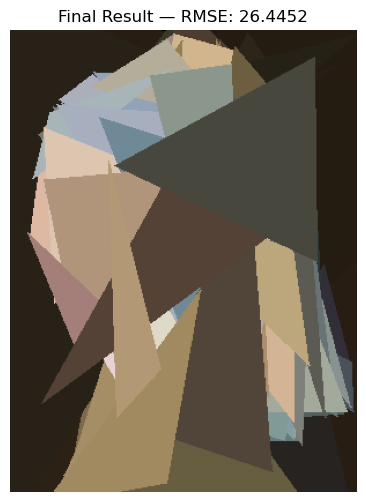

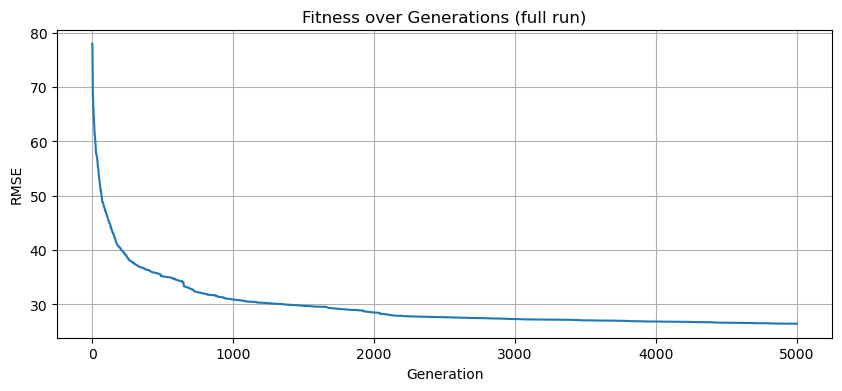

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_12640\1456170957.py:20: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in sorted(glob("output/*.png"))]


Saved evolution.gif


In [ ]:
# ── Final Results ─────────────────────────────────────────────────────────

# Final image
plt.figure(figsize=(5, 6))
plt.imshow(render(best_dna_final).astype(np.uint8))
plt.title(f"Final Result — RMSE: {history_final[-1]:.4f}")
plt.axis("off")
plt.show()

# Fitness over generations
plt.figure(figsize=(10, 4))
plt.plot(history_final)
plt.xlabel("Generation")
plt.ylabel("RMSE")
plt.title("Fitness over Generations (full run)")
plt.grid(True)
plt.show()

# GIF
frames = [imageio.imread(f) for f in sorted(glob("output/*.png"))]
imageio.mimsave("evolution.gif", frames, fps=10)
print("Saved evolution.gif")